In [1]:
# Reiniciar las importaciones correctamente
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt  # Forma alternativa y más explícita de importar
import seaborn as sns
pd.set_option("future.no_silent_downcasting", True)


In [2]:
clientes = pd.read_excel('../clean_data/clientes.xlsx')
detalle_ventas = pd.read_excel('../clean_data/detalles_ventas_clean.xlsx')
productos = pd.read_excel('../clean_data/productos_clean.xlsx')
ventas = pd.read_excel('../clean_data/ventas_clean.xlsx')

df_list = [clientes, detalle_ventas, productos, ventas]

### ESTADISTICAS DESCRIPTIVAS

In [3]:
name_list = ["clientes", "detalle_ventas", "productos", "ventas"]

for i, tabla in enumerate(df_list):
    print(f"\nEstadísticas descriptivas para {name_list[i]}:")
    print("\nInformación general:")
    print(tabla.info())

    print("\nEstadísticas numéricas:")
    print(tabla.describe())
    
    print("\nValores nulos por columna:")
    print(tabla.isnull().sum())

    # Mostrar primeras filas
    print("\nPrimeras filas del dataset:")
    print(tabla.head())

    print("\n" + "="*50)


Estadísticas descriptivas para clientes:

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_cliente      100 non-null    int64         
 1   nombre_cliente  100 non-null    object        
 2   email           100 non-null    object        
 3   ciudad          100 non-null    object        
 4   fecha_alta      100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 4.0+ KB
None

Estadísticas numéricas:
       id_cliente           fecha_alta
count  100.000000                  100
mean    50.500000  2023-02-19 12:00:00
min      1.000000  2023-01-01 00:00:00
25%     25.750000  2023-01-25 18:00:00
50%     50.500000  2023-02-19 12:00:00
75%     75.250000  2023-03-16 06:00:00
max    100.000000  2023-04-10 00:00:00
std     29.011492                  NaN

Valores nulos por 

## Revisión de columnas en cada tabla

In [4]:
# Veamos las columnas de cada DataFrame
print("Columnas en productos:")
print(productos.columns.tolist())
print("\nColumnas en detalle_ventas:")
print(detalle_ventas.columns.tolist())

Columnas en productos:
['id_producto', 'nombre_producto', 'categoria', 'precio_unitario']

Columnas en detalle_ventas:
['id_venta', 'id_producto', 'nombre_producto', 'cantidad', 'precio_unitario', 'importe']


### RECATEGORIZACION DE PRODUCTOS 

In [5]:
df_productos = productos
# setear previamente todo como alimento
KEYWORDS_LIMPIEZA = ['DETERGENTE', 'LAVANDINA', 'JABÓN', 'ESPONJA', 'DESINFECTANTE', 'SUAVIZANTE','DESODORANTE','CEPILLO','TOALLA','DENTAL','PAPEL','LIMPIA','CAPILAR','PISO','SHAMPOO','SERVILLETA','DESENGRASANTE']
df_productos['categoria'] = 'ALIMENTOS'

def clasificar_producto(nombre_producto):
    """Clasifica el producto basado en palabras clave en su nombre."""
    
    for keyword in KEYWORDS_LIMPIEZA:
        if keyword in nombre_producto:
            return 'LIMPIEZA'
            
    return 'ALIMENTOS'

df_productos['categoria_correcta'] = df_productos['nombre_producto'].apply(clasificar_producto)

df_productos['categoria'] = df_productos['categoria_correcta']
df_productos.drop(columns=['categoria_correcta'], inplace=True)

print("--- Dataset Final Reestructurado  ---")
print(df_productos[['nombre_producto', 'categoria']][df_productos['categoria'] == 'LIMPIEZA'].head(50))
# df['Country/Region'] == 'Argentina'

--- Dataset Final Reestructurado  ---
             nombre_producto categoria
51  DETERGENTE LÍQUIDO 750ML  LIMPIEZA
52              LAVANDINA 1L  LIMPIEZA
53          JABÓN DE TOCADOR  LIMPIEZA
54             SHAMPOO 400ML  LIMPIEZA
55        PAPEL HIGIÉNICO X4  LIMPIEZA
56          SERVILLETAS X100  LIMPIEZA
89       TOALLAS HÚMEDAS X50  LIMPIEZA
90       DESODORANTE AEROSOL  LIMPIEZA
91          CREMA DENTAL 90G  LIMPIEZA
92        CEPILLO DE DIENTES  LIMPIEZA
93               HILO DENTAL  LIMPIEZA
94        MASCARILLA CAPILAR  LIMPIEZA
95             SUAVIZANTE 1L  LIMPIEZA
96       LIMPIAVIDRIOS 500ML  LIMPIEZA
97       DESENGRASANTE 500ML  LIMPIEZA
98               ESPONJAS X3  LIMPIEZA
99             TRAPO DE PISO  LIMPIEZA


### UNIFICACION DE DATASETS (MERGE)

In [6]:

df_venta_detalle = detalle_ventas.merge(ventas, on='id_venta', how='left').merge(df_productos, on='id_producto', how='left')
df_todos = df_venta_detalle.merge(clientes, on='id_cliente' , how='left')
display(df_todos.info())
display(df_todos.describe())
display(df_todos.columns)
display(df_todos.head())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_venta           343 non-null    int64         
 1   id_producto        343 non-null    int64         
 2   nombre_producto_x  343 non-null    object        
 3   cantidad           343 non-null    int64         
 4   precio_unitario_x  343 non-null    int64         
 5   importe            343 non-null    int64         
 6   fecha              343 non-null    datetime64[ns]
 7   id_cliente         343 non-null    int64         
 8   nombre_cliente_x   343 non-null    object        
 9   email_x            343 non-null    object        
 10  medio_pago         343 non-null    object        
 11  nombre_producto_y  343 non-null    object        
 12  categoria          343 non-null    object        
 13  precio_unitario_y  343 non-null    int64         
 14  nombre_cli

None

,id_venta,id_producto,cantidad,precio_unitario_x,importe,fecha,id_cliente,precio_unitario_y,fecha_alta
count,343.000000,343.000000,343.000000,343.000000,343.000000,343,343.000000,343.000000,343
mean,61.492711,49.139942,2.962099,2654.495627,7730.078717,2024-03-30 14:12:14.693877504,45.539359,2654.495627,2023-02-14 12:56:40.583090432
min,1.000000,1.000000,1.000000,272.000000,272.000000,2024-01-02 00:00:00,1.000000,272.000000,2023-01-01 00:00:00
25%,31.000000,23.000000,2.000000,1618.500000,3489.000000,2024-02-10 12:00:00,20.000000,1618.500000,2023-01-20 00:00:00
50%,61.000000,47.000000,3.000000,2512.000000,6702.000000,2024-03-26 00:00:00,43.000000,2512.000000,2023-02-12 00:00:00
75%,93.000000,76.000000,4.000000,3876.000000,10231.500000,2024-05-21 00:00:00,67.000000,3876.000000,2023-03-08 00:00:00
max,120.000000,100.000000,5.000000,4982.000000,24865.000000,2024-06-28 00:00:00,100.000000,4982.000000,2023-04-10 00:00:00
std,34.835525,29.135461,1.366375,1308.694720,5265.543077,NaN,28.436922,1308.694720,NaN


Index(['id_venta', 'id_producto', 'nombre_producto_x', 'cantidad',
       'precio_unitario_x', 'importe', 'fecha', 'id_cliente',
       'nombre_cliente_x', 'email_x', 'medio_pago', 'nombre_producto_y',
       'categoria', 'precio_unitario_y', 'nombre_cliente_y', 'email_y',
       'ciudad', 'fecha_alta'],
      dtype='object')

,id_venta,id_producto,nombre_producto_x,cantidad,precio_unitario_x,importe,fecha,id_cliente,nombre_cliente_x,email_x,medio_pago,nombre_producto_y,categoria,precio_unitario_y,nombre_cliente_y,email_y,ciudad,fecha_alta
0,1,90,TOALLAS HÚMEDAS X50,1,2902,2902,2024-06-19,62,GUADALUPE ROMERO,GUADALUPE.ROMERO@MAIL.COM,TARJETA,TOALLAS HÚMEDAS X50,LIMPIEZA,2902,GUADALUPE ROMERO,GUADALUPE.ROMERO@MAIL.COM,CARLOS PAZ,2023-03-03
1,2,82,ACEITUNAS NEGRAS 200G,5,2394,11970,2024-03-17,49,OLIVIA GOMEZ,OLIVIA.GOMEZ@MAIL.COM,QR,ACEITUNAS NEGRAS 200G,ALIMENTOS,2394,OLIVIA GOMEZ,OLIVIA.GOMEZ@MAIL.COM,RIO CUARTO,2023-02-18
2,2,39,HELADO VAINILLA 1L,5,469,2345,2024-03-17,49,OLIVIA GOMEZ,OLIVIA.GOMEZ@MAIL.COM,QR,HELADO VAINILLA 1L,ALIMENTOS,469,OLIVIA GOMEZ,OLIVIA.GOMEZ@MAIL.COM,RIO CUARTO,2023-02-18
3,2,70,FERNET 750ML,2,4061,8122,2024-03-17,49,OLIVIA GOMEZ,OLIVIA.GOMEZ@MAIL.COM,QR,FERNET 750ML,ALIMENTOS,4061,OLIVIA GOMEZ,OLIVIA.GOMEZ@MAIL.COM,RIO CUARTO,2023-02-18
4,2,22,MEDIALUNAS DE MANTECA,1,2069,2069,2024-03-17,49,OLIVIA GOMEZ,OLIVIA.GOMEZ@MAIL.COM,QR,MEDIALUNAS DE MANTECA,ALIMENTOS,2069,OLIVIA GOMEZ,OLIVIA.GOMEZ@MAIL.COM,RIO CUARTO,2023-02-18


Todos id's, emails, nombre cliente, 

In [7]:
df = df_todos

df = df.drop(columns=['id_venta','id_producto','nombre_producto_x','precio_unitario_x','nombre_cliente_x','email_x','nombre_cliente_y','email_y','id_cliente'])
df.rename(columns={'nombre_producto_y':'producto','precio_unitario_y':'precio','importe':'total','fecha':'fecha_venta','fecha_alta':'fecha_alta_cli'}, inplace=True)

display(df.tail())
df = df[['producto','categoria','cantidad','precio','total','medio_pago','fecha_venta','ciudad','fecha_alta_cli']]
display(df.tail())

,cantidad,total,fecha_venta,medio_pago,producto,categoria,precio,ciudad,fecha_alta_cli
338,2,8122,2024-02-09,EFECTIVO,FERNET 750ML,ALIMENTOS,4061,CORDOBA,2023-03-25
339,3,6426,2024-02-09,EFECTIVO,CEPILLO DE DIENTES,LIMPIEZA,2142,CORDOBA,2023-03-25
340,2,1454,2024-02-09,EFECTIVO,AZÚCAR 1KG,ALIMENTOS,727,CORDOBA,2023-03-25
341,5,3725,2024-02-07,QR,FIDEOS SPAGHETTI 500G,ALIMENTOS,745,RIO CUARTO,2023-02-20
342,5,7855,2024-04-21,TARJETA,PAN LACTAL BLANCO,ALIMENTOS,1571,CORDOBA,2023-03-13


,producto,categoria,cantidad,precio,total,medio_pago,fecha_venta,ciudad,fecha_alta_cli
338,FERNET 750ML,ALIMENTOS,2,4061,8122,EFECTIVO,2024-02-09,CORDOBA,2023-03-25
339,CEPILLO DE DIENTES,LIMPIEZA,3,2142,6426,EFECTIVO,2024-02-09,CORDOBA,2023-03-25
340,AZÚCAR 1KG,ALIMENTOS,2,727,1454,EFECTIVO,2024-02-09,CORDOBA,2023-03-25
341,FIDEOS SPAGHETTI 500G,ALIMENTOS,5,745,3725,QR,2024-02-07,RIO CUARTO,2023-02-20
342,PAN LACTAL BLANCO,ALIMENTOS,5,1571,7855,TARJETA,2024-04-21,CORDOBA,2023-03-13


In [8]:
#Transformar datos
medios = {"EFECTIVO": 0 , "TARJETA": 1, "QR":2, "TRANSFERENCIA": 3}
# anotar como observacion que es cada codigo de metodo de pago
#{"EFECTIVO": 0 , "TARJETA": 1, "QR":2, "TRANSFERENCIA": 3}
df["medio_pago"] = df["medio_pago"].replace(medios).infer_objects(copy=False)


ciudades = {'CARLOS PAZ':0, 'RIO CUARTO':1, 'MENDIOLAZA':2, 'ALTA GRACIA':3, 'VILLA MARIA': 4,'CORDOBA': 5}
#{'CARLOS PAZ':0, 'RIO CUARTO':1, 'MENDIOLAZA':2, 'ALTA GRACIA':3, 'VILLA MARIA': 4,'CORDOBA': 5}
df["ciudad"] = df["ciudad"].replace(ciudades).infer_objects(copy=False)


categorias = {'LIMPIEZA':0, 'ALIMENTOS':1}
#{'LIMPIEZA':0, 'ALIMENTOS':1}
df["categoria"] = df["categoria"].replace(categorias).infer_objects(copy=False)

display(df.tail())
display(df.sample(20))



,producto,categoria,cantidad,precio,total,medio_pago,fecha_venta,ciudad,fecha_alta_cli
338,FERNET 750ML,1,2,4061,8122,0,2024-02-09,5,2023-03-25
339,CEPILLO DE DIENTES,0,3,2142,6426,0,2024-02-09,5,2023-03-25
340,AZÚCAR 1KG,1,2,727,1454,0,2024-02-09,5,2023-03-25
341,FIDEOS SPAGHETTI 500G,1,5,745,3725,2,2024-02-07,1,2023-02-20
342,PAN LACTAL BLANCO,1,5,1571,7855,1,2024-04-21,5,2023-03-13


,producto,categoria,cantidad,precio,total,medio_pago,fecha_venta,ciudad,fecha_alta_cli
281,TURRÓN 50G,1,4,503,2012,0,2024-03-28,5,2023-03-13
46,FANTA NARANJA 1.5L,1,5,2033,10165,2,2024-06-11,0,2023-03-22
69,VERDURAS CONGELADAS MIX,1,4,4289,17156,3,2024-02-25,0,2023-01-09
132,JABÓN DE TOCADOR,0,5,1592,7960,2,2024-01-26,5,2023-03-25
288,MASCARILLA CAPILAR,0,2,1581,3162,2,2024-06-17,5,2023-03-27
170,DESODORANTE AEROSOL,0,4,4690,18760,3,2024-04-04,0,2023-03-22
195,HAMBURGUESAS CONGELADAS X4,1,4,2420,9680,2,2024-06-02,1,2023-02-09
31,SOPA INSTANTÁNEA POLLO,1,3,1679,5037,0,2024-06-28,5,2023-04-06
110,ACEITUNAS VERDES 200G,1,4,2520,10080,0,2024-03-05,5,2023-01-05
86,QUESO AZUL 150G,1,5,1645,8225,1,2024-05-22,2,2023-01-19


In [9]:
# Procesamiento de fechas
df['fecha_venta'] = pd.to_datetime(df['fecha_venta'])
df['mes'] = df['fecha_venta'].dt.to_period('M')

df["cuatrimestre"] = ((df["fecha_venta"].dt.month - 1) // 4 + 1).astype(int)
df["anio_cuatrimestre"] = df["fecha_venta"].dt.year.astype(str) + "-C" + df["cuatrimestre"].astype(str)


# Mostrar el resultado
print("\nPrimeras filas con las nuevas columnas temporales:")
display(df.head())




Primeras filas con las nuevas columnas temporales:


,producto,categoria,cantidad,precio,total,medio_pago,fecha_venta,ciudad,fecha_alta_cli,mes,cuatrimestre,anio_cuatrimestre
0,TOALLAS HÚMEDAS X50,0,1,2902,2902,1,2024-06-19,0,2023-03-03,2024-06,2,2024-C2
1,ACEITUNAS NEGRAS 200G,1,5,2394,11970,2,2024-03-17,1,2023-02-18,2024-03,1,2024-C1
2,HELADO VAINILLA 1L,1,5,469,2345,2,2024-03-17,1,2023-02-18,2024-03,1,2024-C1
3,FERNET 750ML,1,2,4061,8122,2,2024-03-17,1,2023-02-18,2024-03,1,2024-C1
4,MEDIALUNAS DE MANTECA,1,1,2069,2069,2,2024-03-17,1,2023-02-18,2024-03,1,2024-C1


## Análisis Visual de los Datos - OUTLIERS

A continuación, realizaremos diferentes visualizaciones para entender mejor los patrones en nuestros datos:

         cantidad       precio         total
count  343.000000   343.000000    343.000000
mean     2.962099  2654.495627   7730.078717
std      1.366375  1308.694720   5265.543077
min      1.000000   272.000000    272.000000
25%      2.000000  1618.500000   3489.000000
50%      3.000000  2512.000000   6702.000000
75%      4.000000  3876.000000  10231.500000
max      5.000000  4982.000000  24865.000000


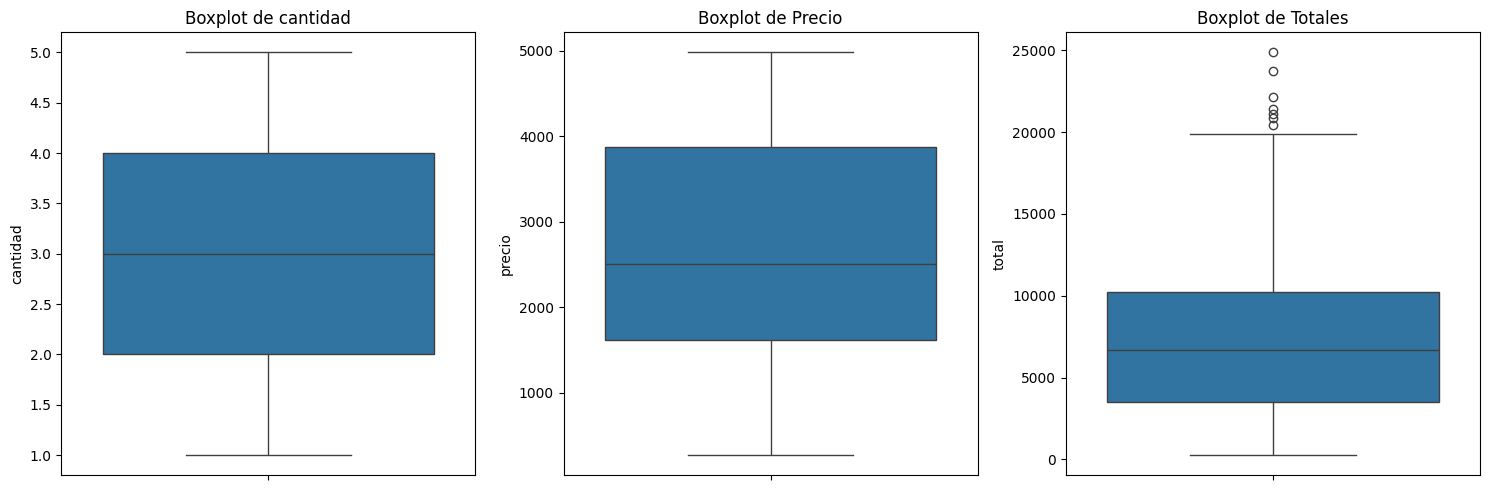


==================== Valores extremos para CANTIDAD ====================

Estadísticas usando método IQR (igual que boxplot):
Q1: 2.00
Q3: 4.00
IQR: 2.00
Límite inferior: 0.00
Límite superior: 7.00

==================== Valores extremos para PRECIO ====================

Estadísticas usando método IQR (igual que boxplot):
Q1: 1618.50
Q3: 3876.00
IQR: 2257.50
Límite inferior: 0.00
Límite superior: 7262.25

==================== Valores extremos para TOTAL ====================

Estadísticas usando método IQR (igual que boxplot):
Q1: 3489.00
Q3: 10231.50
IQR: 6742.50
Límite inferior: 0.00
Límite superior: 20345.25

Outliers detectados: 7 registros
Muestra de outliers:


,producto,total
41,BARRITA DE CEREAL 30G,22150
54,PIZZA CONGELADA MUZZARELLA,21430
141,CARAMELOS MASTICABLES,23760
175,ENERGÉTICA NITRO 500ML,21090
208,PEPSI 1.5L,24865


In [10]:

def analizar_valores_extremos_iqr(df, columna):
    """Analiza outliers usando método IQR (igual que boxplot)"""
    print(f"\n{'='*20} Valores extremos para {columna.upper()} {'='*20}")
    
    # Calcular Q1, Q3 e IQR
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calcular límites
    lower_bound = max(0, Q1 - 1.5*IQR)
    upper_bound = Q3 + 1.5*IQR
    
    print(f"\nEstadísticas usando método IQR (igual que boxplot):")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite inferior: {lower_bound:.2f}")
    print(f"Límite superior: {upper_bound:.2f}")
    
    # Identificar outliers
    outliers = df[(df[columna] < lower_bound) | (df[columna] > upper_bound)]
    
    if not outliers.empty:
        print(f"\nOutliers detectados: {len(outliers)} registros")
        print("Muestra de outliers:")
        display(outliers[['producto', columna]].head())
    
    return outliers


print(df[['cantidad','precio','total']].describe())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, y='cantidad', ax=ax1)
ax1.set_title('Boxplot de cantidad')

sns.boxplot(data=df, y='precio', ax=ax2)
ax2.set_title('Boxplot de Precio')

sns.boxplot(data=df, y='total', ax=ax3)
ax3.set_title('Boxplot de Totales')



# Ajustar el layout
plt.tight_layout()
plt.show()

#valores extremos para las variables que son  numéricas
for columna in ['cantidad', 'precio', 'total']:
    analizar_valores_extremos_iqr(df, columna)

### Se borraran registros por fuera de los limites (outliers)

In [11]:
df_limpio = df.copy()
# Eliminar outliers en 'total'


### ANALISIS DE CORRELACIONES 


=========== CORRELACIONES PARA  ===========
              categoria  cantidad    precio     total  medio_pago    ciudad  \
categoria      1.000000 -0.006661 -0.002360  0.005777   -0.009581 -0.006448   
cantidad      -0.006661  1.000000 -0.074483  0.599723   -0.019320  0.031841   
precio        -0.002360 -0.074483  1.000000  0.679298   -0.036067 -0.054044   
total          0.005777  0.599723  0.679298  1.000000   -0.046059 -0.014625   
medio_pago    -0.009581 -0.019320 -0.036067 -0.046059    1.000000 -0.248395   
ciudad        -0.006448  0.031841 -0.054044 -0.014625   -0.248395  1.000000   
cuatrimestre   0.004391  0.043525  0.082084  0.097794    0.003841 -0.070746   

              cuatrimestre  
categoria         0.004391  
cantidad          0.043525  
precio            0.082084  
total             0.097794  
medio_pago        0.003841  
ciudad           -0.070746  
cuatrimestre      1.000000  


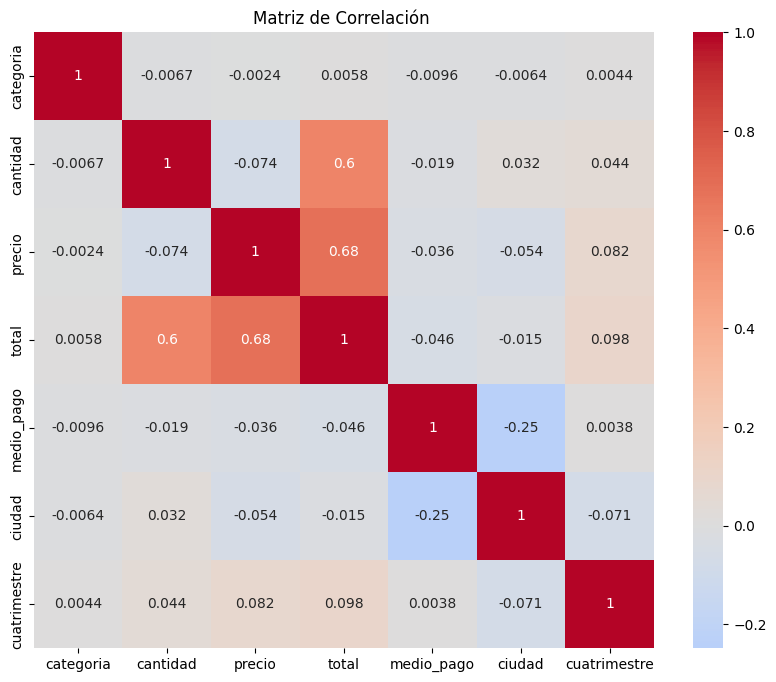


Correlaciones más significativas:
precio    total       0.679298
total     precio      0.679298
cantidad  total       0.599723
total     cantidad    0.599723
dtype: float64


In [12]:

print(f"\n=========== CORRELACIONES PARA  ===========")

numericas = df.select_dtypes(include=[np.number])

if not numericas.empty:
    corr = numericas.corr()
    print(corr)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
    ax.set_title(f'Matriz de Correlación ')
    plt.show()
    
    print("\nCorrelaciones más significativas:")
    corr_unstack = corr.unstack()
    corr_sorted = corr_unstack[abs(corr_unstack) > 0.5]
    corr_sorted = corr_sorted[corr_sorted != 1.0] #elimino autocorrelaciones
    if not corr_sorted.empty:
        print(corr_sorted.sort_values(ascending=False))
    else:
        print("No se encontraron correlaciones significativas (>0.5)")
else:
    print(f"No hay variables numéricas en para calcular correlaciones")


### GRAFICOS VARIOS 
verificar validez

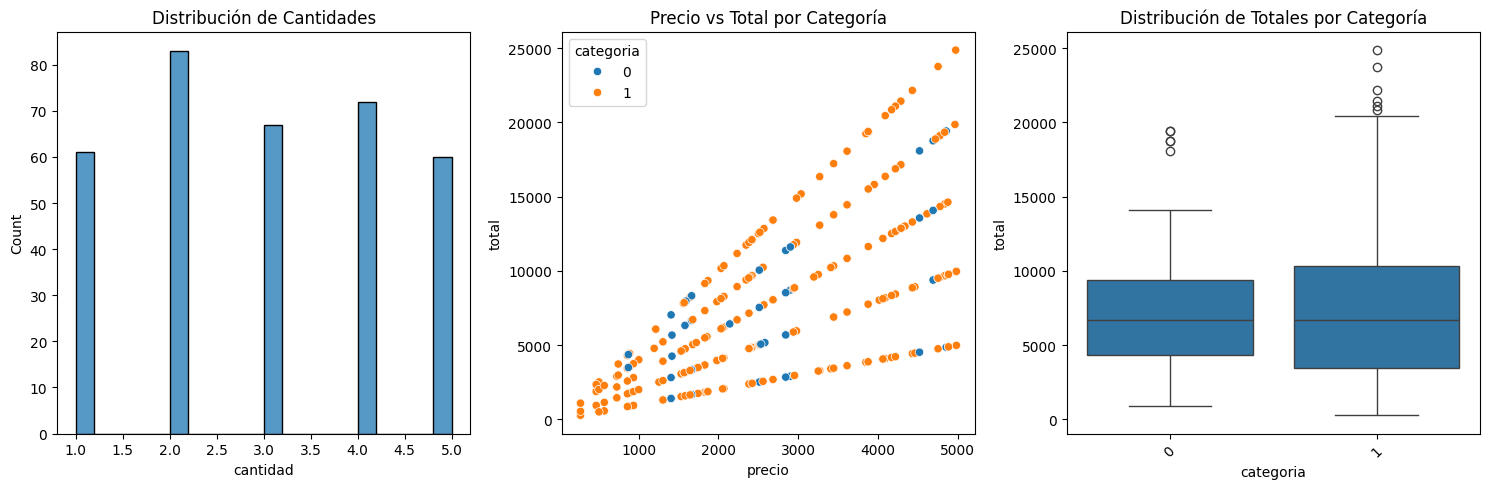

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# 1. Distribución de cantidades
sns.histplot(data=df, x='cantidad', bins=20, ax=ax1)
ax1.set_title('Distribución de Cantidades')

# 2. Relación Precio vs Total
sns.scatterplot(data=df, x='precio', y='total', hue='categoria', ax=ax2)
ax2.set_title('Precio vs Total por Categoría')

# 3. Distribución de totales por categoría
sns.boxplot(data=df, x='categoria', y='total', ax=ax3)
ax3.set_title('Distribución de Totales por Categoría')
ax3.tick_params(axis='x', rotation=45)

# Ajustar el layout
plt.tight_layout()
plt.show()

## Interpretación de Resultados

Del análisis realizado podemos concluir:

1. **Distribución de Cantidades**
   - La mayoría de las ventas son de pocas unidades
   - Hay algunos casos de ventas con cantidades grandes
   - La distribución está sesgada hacia la derecha

2. **Relación Precio-Total**
   - Existe una correlación positiva entre precio y total
   - Las categorías muestran patrones diferentes
   - Algunos productos tienen precios significativamente más altos

3. **Análisis por Categoría**
   - Hay diferencias notables en los totales entre categorías
   - Cada categoría tiene sus propios rangos de precios
   - Se identifican algunos valores atípicos importantes

